# **Projeto de Graduação em Computação II [2026-Q1]**

Universidade Federal do ABC

Orientador Carlos da Silva dos Santos

### **EQUIPE**

---

Caio Cardoso Dos Santos - RA: 11202021632

Victor Ravazio de Lima - RA: 11201920941

### **IMPLEMENTAÇÃO**
---

In [44]:
# modulo para importar dataset a partir de um link
!pip install gdown

In [45]:
!pip install emoji

In [46]:
#Bibliotecas
import pandas as pd
import numpy as np
import json
from datetime import datetime
from google.colab import files
import gdown
import matplotlib.pyplot as plt


In [47]:
# baixando dataset para o collab
import gdown

file_id = "1vkkPMa3qlmOnhhAcqrVQy-bt4UyjEKdT"
url = f"https://drive.google.com/uc?id={file_id}"

gdown.download(url, "aborto.json", quiet=False)

Downloading...
From (original): https://drive.google.com/uc?id=1vkkPMa3qlmOnhhAcqrVQy-bt4UyjEKdT
From (redirected): https://drive.google.com/uc?id=1vkkPMa3qlmOnhhAcqrVQy-bt4UyjEKdT&confirm=t&uuid=e5f8b34f-349d-41ed-8cd6-c6d31471ef68
To: /content/aborto.json
100%|██████████| 567M/567M [00:07<00:00, 71.7MB/s]


'aborto.json'

In [48]:
#obtendo o caminho do dataset
file_path = "aborto.json"


In [49]:
#importando e manipulando o dataset em json Lines (cada linha deste "json" é um "json")

data = [] #lista de jsons - basicamente um dicionario
with open(file_path, "r", encoding="utf-8") as f:
    for line in f:
        data.append(json.loads(line)) #converte o Json em dicionario e adiciona a lista "data"

In [50]:
#extraindo texto completo
def extract_full_text(tweet_obj):
    if tweet_obj.get("truncated"):
        return tweet_obj.get("extended_tweet", {}).get("full_text", tweet_obj.get("text", ""))
    else:
        return tweet_obj.get("text", "")

In [51]:
def has_image(tweet_obj):
    # checa o próprio tweet
    if "extended_entities" in tweet_obj:
        media = tweet_obj["extended_entities"].get("media", [])
        if any(m.get("type") == "photo" for m in media):
            return True

    #Resolvendo o "problema" - extended entities pode estar em "extended_tweet" e não no tweet base
    if "extended_tweet" in tweet_obj:
        if "extended_entities" in tweet_obj["extended_tweet"]:
            media = tweet_obj["extended_tweet"]["extended_entities"].get("media", [])
            if any(m.get("type") == "photo" for m in media):
                return True

    # checa quote (se existir)
    if tweet_obj.get("is_quote_status") and "quoted_status" in tweet_obj:
        quoted = tweet_obj["quoted_status"]
        if "extended_entities" in quoted:
            media = quoted["extended_entities"].get("media", [])
            if any(m.get("type") == "photo" for m in media):
                return True

    return False

In [52]:
#Construindo lista estruturada
processed = [] #lista de dicionarios (cada tweet é um dicionario - no fim é facil converter dicionario num df)

for tweet in data: #data é uma lista de dicionarios e tweet itera dicionario em dicionario em data

    # Identificando se é retweet
    if "retweeted_status" in tweet:
        base_tweet = tweet["retweeted_status"] #retweeted_status é um subdicionario dentro do dicionario tweets - contem as infos do retweet como texto, autor e etc
        is_retweet = True

        original_tweet_date = base_tweet.get("created_at")
        retweeter_id = tweet.get("user", {}).get("id_str")
        retweet_date = tweet.get("created_at")

    #Caso contrario, é um tweet original
    else:
        base_tweet = tweet
        is_retweet = False

        original_tweet_date = tweet.get("created_at")
        retweeter_id = None
        retweet_date = None

    #verificando se existe imagem (caso sim, desconsiderar o tweet)
    if has_image(base_tweet):
      continue

    # Tratando quotes (respostas)
    is_quote = base_tweet.get("is_quote_status", False) #verificando se é um quote

    if is_quote and "quoted_status" in base_tweet: #se for quote e o campo quote_status (dicionario de elementos, igual retweet status) não for null
        quoted_tweet = base_tweet["quoted_status"] #quoted_status é um subdicionario dentro do dicionario tweets - contem as infos do quote como texto, autor e etc

        quoted_text = extract_full_text(quoted_tweet)
        quoted_tweet_id = quoted_tweet.get("id_str")
        quoted_user_id = quoted_tweet.get("user", {}).get("id_str")
    else:
        quoted_text = None
        quoted_tweet_id = None
        quoted_user_id = None


    #Tratando reply
    is_reply = base_tweet.get("in_reply_to_status_id", False) is not None

    reply_to_tweet_id = base_tweet.get("in_reply_to_status_id_str")
    reply_to_user_id = base_tweet.get("in_reply_to_user_id_str")
    reply_to_screen_name = base_tweet.get("in_reply_to_screen_name")

    #Produzindo o dicionario do tweet e adicionando na lista
    text = extract_full_text(base_tweet)

    processed.append({
        "tweet_id": base_tweet.get("id_str"),
        "user_id_original": base_tweet.get("user", {}).get("id_str"),
        "text": text,
        "created_at_original": original_tweet_date,

        "retweet_count": base_tweet.get("retweet_count", 0),
        "like_count": base_tweet.get("favorite_count", 0),

        # retweet info
        "is_retweet": is_retweet,
        "retweeter_user_id": retweeter_id,
        "retweet_created_at": retweet_date,

        # quote info
        "is_quote": is_quote,
        "quoted_tweet_id": quoted_tweet_id,
        "quoted_user_id": quoted_user_id,
        "quoted_text": quoted_text,

        # --- REPLY ---
        "is_reply": is_reply,
        "reply_to_tweet_id": reply_to_tweet_id,
        "reply_to_user_id": reply_to_user_id,
        "reply_to_screen_name": reply_to_screen_name
    })

In [53]:
#Criando DataFrame

df = pd.DataFrame(processed)

df
#print(df.shape)

,tweet_id,user_id_original,text,created_at_original,retweet_count,like_count,is_retweet,retweeter_user_id,retweet_created_at,is_quote,quoted_tweet_id,quoted_user_id,quoted_text,is_reply,reply_to_tweet_id,reply_to_user_id,reply_to_screen_name
0,1250542322313560064,1053003526052474881,"STF, o câncer do Brasil, agora quer decidir qu...",Wed Apr 15 21:51:38 +0000 2020,54,85,True,1015738630411902978,Wed Apr 15 22:56:26 +0000 2020,False,None,None,None,False,None,None,None
1,1250524480134361089,3062568484,#AbortoNAO é da sua conta\n\nse o corpo nao é ...,Wed Apr 15 20:40:44 +0000 2020,246,736,True,1073292364326801408,Wed Apr 15 22:56:26 +0000 2020,False,None,None,None,False,None,None,None
2,1250558630656704517,1044570099074650112,Alô STF... repitam comigo:\n\n#AbortoNao,Wed Apr 15 22:56:26 +0000 2020,0,0,False,None,None,False,None,None,None,False,None,None,None
3,1250531402355036165,1087259768,STF quer aplicar a medida enquanto a gente não...,Wed Apr 15 21:08:14 +0000 2020,1436,4040,True,87768090,Wed Apr 15 22:56:26 +0000 2020,False,None,None,None,False,None,None,None
4,1250550843599970308,350476403,"O que a Bíblia fala sobre o aborto?\n\n""Antes ...",Wed Apr 15 22:25:29 +0000 2020,144,418,True,1221110775424737284,Wed Apr 15 22:56:26 +0000 2020,False,None,None,None,False,None,None,None
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
56547,1250582071006957569,82271629,Sério q a esquerda está levantando tag p/ apoi...,Thu Apr 16 00:29:35 +0000 2020,1811,6841,True,2198802516,Thu Apr 16 20:10:00 +0000 2020,False,None,None,None,False,None,None,None
56548,1250879142687584261,1222610949728886785,"No dia 24, na próxima semana, o STF vai votar ...",Thu Apr 16 20:10:02 +0000 2020,0,0,False,None,None,False,None,None,None,False,None,None,None
56549,1250561465595105282,1196600981749932033,CURIOSIDADE: 100% das pessoas que usam a hasht...,Wed Apr 15 23:07:42 +0000 2020,2207,12358,True,1147493662164770816,Thu Apr 16 20:10:06 +0000 2020,False,None,None,None,False,None,None,None
56550,1250531402355036165,1087259768,STF quer aplicar a medida enquanto a gente não...,Wed Apr 15 21:08:14 +0000 2020,2849,9361,False,None,None,False,None,None,None,False,None,None,None


In [54]:
# Buscando textos originais dos replys - O texto original (que esta sendo respondido) não está no tweet que esta respondendo: ideia buscar neste dataset pelo id neste dataset
# garantindo ids em strings
df["tweet_id"] = df["tweet_id"].astype(str)
df["reply_to_tweet_id"] = df["reply_to_tweet_id"].astype(str)

# criar dicionário id -> texto
id_to_text = dict(zip(df["tweet_id"], df["text"])) # Organizando o dataset num dicionario: Chave: tweet id, conteudo: texto - isso facilita a busca (ex: ao fornecer a chave X, retorna seu texto Y)

# Criando reply text: Basicamente varre cada reply_tweet_id do df, e se não for none, aplica no dicionario, ou seja, busca no dicionario aquele tweet id do reply como chave - se encontrar, retorna o conteudo, se não, none
df["reply_text"] = df["reply_to_tweet_id"].map(id_to_text)

In [55]:
#Removendo URLs
import re
import emoji

def clean_text(text):
    if not isinstance(text, str):
        return ""

    text = emoji.replace_emoji(text, replace='')
    text = re.sub(r"http\S+", "", text)
    text = re.sub(r"@\w+", "", text)
    text = re.sub(r"RT\s+", "", text)
    text = re.sub(r"\n", " ", text)
    return text.strip()

df["text"] = df["text"].apply(clean_text)
df["quoted_text"] = df["quoted_text"].apply(clean_text)
df["reply_text"] = df["reply_text"].apply(clean_text)

In [56]:
#removendo textos vazios
df = df[df["text"].notnull()]
df = df[df["text"].str.strip() != ""]
print(df.shape)

(56552, 18)


In [57]:
#replys "usáveis" - Antes de remover duplicatas
replys = df.loc[(df["is_reply"] == True) & (df["reply_text"].str.strip() != "")]

In [58]:
replys

,tweet_id,user_id_original,text,created_at_original,retweet_count,like_count,is_retweet,retweeter_user_id,retweet_created_at,is_quote,quoted_tweet_id,quoted_user_id,quoted_text,is_reply,reply_to_tweet_id,reply_to_user_id,reply_to_screen_name,reply_text
28,1250558657739345922,897894817681858560,#AbortoNAO vida sim,Wed Apr 15 22:56:32 +0000 2020,0,0,False,None,None,False,None,None,,True,1250528187911680001,975127727501185025,CarlaZambelli38,"Bora subir, robozada? #AbortoNao"
31,1250558661937766401,1189604917020889088,Que Porra é essa ? #AbortoNao,Wed Apr 15 22:56:33 +0000 2020,0,0,False,None,None,False,None,None,,True,1250531402355036165,1087259768,taoquei1,STF quer aplicar a medida enquanto a gente não...
35,1250558670515113985,981500141600432129,Assassinato nunca! #AbortoNAO,Wed Apr 15 22:56:35 +0000 2020,0,0,False,None,None,False,None,None,,True,1250538573935321094,350476403,Jouberth19,Enquanto lutamos pela nossa vida contra o covi...
48,1250558699573297152,348759234,Vergonha desse STF #AbortoNAO,Wed Apr 15 22:56:42 +0000 2020,0,0,False,None,None,False,None,None,,True,1250531402355036165,1087259768,taoquei1,STF quer aplicar a medida enquanto a gente não...
58,1250529001875128320,1248766993517477888,Gostaria de informar que devido a grande reper...,Wed Apr 15 20:58:42 +0000 2020,8,54,True,373058006,Wed Apr 15 22:56:46 +0000 2020,False,None,None,,True,1250528187911680001,975127727501185025,CarlaZambelli38,"Bora subir, robozada? #AbortoNao"
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
56429,1250600479362605059,1206256258656931847,#AbortoNAO STF respeite a VIDA de INOCENTES!,Thu Apr 16 01:42:43 +0000 2020,1,2,True,4034757077,Thu Apr 16 20:00:35 +0000 2020,False,None,None,,True,1250568995520032770,350476403,Jouberth19,A tag #AbortoNao está em 1º lugar nos trends c...
56441,1250877047980863488,4034757077,#AbortoNao ninguém tem o direito de tirar a vi...,Thu Apr 16 20:01:43 +0000 2020,0,0,False,None,None,False,None,None,,True,1250568995520032770,350476403,Jouberth19,A tag #AbortoNao está em 1º lugar nos trends c...
56470,1250877595211743233,582380587,O que é dred scott case? #AbortoNao,Thu Apr 16 20:03:53 +0000 2020,0,0,False,None,None,False,None,None,,True,1250604793325858818,172572347,opropriopontes,STF pode estar cometendo o seu maior erro: pau...
56472,1250877639549739010,1213494698142101506,De jeito nenhum! #AbortoNao,Thu Apr 16 20:04:04 +0000 2020,0,0,False,None,None,False,None,None,,True,1250626106618777600,350476403,Jouberth19,A tag #AbortoNao passou dos 100k. Enquanto iss...


In [59]:
#quotes - Antes de remover duplicatas

quotes = df.loc[(df["is_quote"] == True) & (df["quoted_text"].str.strip() != "")]
quotes

,tweet_id,user_id_original,text,created_at_original,retweet_count,like_count,is_retweet,retweeter_user_id,retweet_created_at,is_quote,quoted_tweet_id,quoted_user_id,quoted_text,is_reply,reply_to_tweet_id,reply_to_user_id,reply_to_screen_name,reply_text
9,1250556519118262272,4857849189,"Independente se você tem religião ou não, o tr...",Wed Apr 15 22:48:03 +0000 2020,2,2,True,859178965331783683,Wed Apr 15 22:56:28 +0000 2020,True,1250531402355036165,1087259768,STF quer aplicar a medida enquanto a gente não...,False,None,None,None,
20,1250558648595763212,3711957436,eu peço para que você faça mais por crianças j...,Wed Apr 15 22:56:30 +0000 2020,0,0,False,None,None,True,1250551154762711045,869662809075929088,"Eu peço a quem for a favor do aborto, para ref...",False,None,None,None,
25,1250558653415002117,1204537219341529090,vc é um homem cis q se sua namorada engravidar...,Wed Apr 15 22:56:31 +0000 2020,0,0,False,None,None,True,1250520793349570561,172165361,"Toffoli, um lacaio da OMS, pautou ADI do abort...",False,None,None,None,
29,1250553831672500236,1119256312062402560,Difícil demais viver nesse País! A que ponto c...,Wed Apr 15 22:37:22 +0000 2020,6,10,True,34629513,Wed Apr 15 22:56:33 +0000 2020,True,1250545512983539718,391606213,"Médico pedófilo, Fábio Duarte, estava preso p/...",False,None,None,None,
30,1250558661052727297,718146038482223104,Primeiramente #foradoria segundamente nao somo...,Wed Apr 15 22:56:33 +0000 2020,0,0,False,None,None,True,1250558157102952448,302556418,#AbortoNao A hidroxicloroquina pode ter efeito...,False,None,None,None,
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
56530,1250856868861431809,1119013478851915776,Nasceu sem massa cefálica. #UnidosComBolsonaro,Thu Apr 16 18:41:31 +0000 2020,1,0,True,1103654230219517955,Thu Apr 16 20:08:58 +0000 2020,True,1250818840122064901,635764127,"O que leva um feto, que evoluiu e cresceu, vir...",False,None,None,None,
56535,1250863297244602368,813967874,Petistas criminosos comunistas fdp. Estão mata...,Thu Apr 16 19:07:04 +0000 2020,1,1,True,817420441,Thu Apr 16 20:09:12 +0000 2020,True,1250577060331995136,784751173265948672,DENÚNCIA: médicos usaram superdosagem em cobai...,False,None,None,None,
56536,1250878960520572931,765543343581528064,é um direito sim! Mais vale abortar logo do qu...,Thu Apr 16 20:09:19 +0000 2020,0,0,False,None,None,True,1250788117386330115,605414528,Já que tenho útero posso opinar. Aborto é imor...,False,None,None,None,
56539,1250878992175030278,709698858,Esses dois são judeus? Não sabia,Thu Apr 16 20:09:26 +0000 2020,0,0,False,None,None,True,1250861271974584321,172572347,S/ aborto e eventual voto de Fux e Barroso: a...,False,None,None,None,


In [60]:
#genéricos - Antes de remover duplicatas

generics = df.loc[(df["is_quote"] == False) & (df["is_reply"] == False)]
generics

,tweet_id,user_id_original,text,created_at_original,retweet_count,like_count,is_retweet,retweeter_user_id,retweet_created_at,is_quote,quoted_tweet_id,quoted_user_id,quoted_text,is_reply,reply_to_tweet_id,reply_to_user_id,reply_to_screen_name,reply_text
0,1250542322313560064,1053003526052474881,"STF, o câncer do Brasil, agora quer decidir qu...",Wed Apr 15 21:51:38 +0000 2020,54,85,True,1015738630411902978,Wed Apr 15 22:56:26 +0000 2020,False,None,None,,False,None,None,None,
1,1250524480134361089,3062568484,#AbortoNAO é da sua conta se o corpo nao é se...,Wed Apr 15 20:40:44 +0000 2020,246,736,True,1073292364326801408,Wed Apr 15 22:56:26 +0000 2020,False,None,None,,False,None,None,None,
2,1250558630656704517,1044570099074650112,Alô STF... repitam comigo: #AbortoNao,Wed Apr 15 22:56:26 +0000 2020,0,0,False,None,None,False,None,None,,False,None,None,None,
3,1250531402355036165,1087259768,STF quer aplicar a medida enquanto a gente não...,Wed Apr 15 21:08:14 +0000 2020,1436,4040,True,87768090,Wed Apr 15 22:56:26 +0000 2020,False,None,None,,False,None,None,None,
4,1250550843599970308,350476403,"O que a Bíblia fala sobre o aborto? ""Antes qu...",Wed Apr 15 22:25:29 +0000 2020,144,418,True,1221110775424737284,Wed Apr 15 22:56:26 +0000 2020,False,None,None,,False,None,None,None,
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
56547,1250582071006957569,82271629,Sério q a esquerda está levantando tag p/ apoi...,Thu Apr 16 00:29:35 +0000 2020,1811,6841,True,2198802516,Thu Apr 16 20:10:00 +0000 2020,False,None,None,,False,None,None,None,
56548,1250879142687584261,1222610949728886785,"No dia 24, na próxima semana, o STF vai votar ...",Thu Apr 16 20:10:02 +0000 2020,0,0,False,None,None,False,None,None,,False,None,None,None,
56549,1250561465595105282,1196600981749932033,CURIOSIDADE: 100% das pessoas que usam a hasht...,Wed Apr 15 23:07:42 +0000 2020,2207,12358,True,1147493662164770816,Thu Apr 16 20:10:06 +0000 2020,False,None,None,,False,None,None,None,
56550,1250531402355036165,1087259768,STF quer aplicar a medida enquanto a gente não...,Wed Apr 15 21:08:14 +0000 2020,2849,9361,False,None,None,False,None,None,,False,None,None,None,


In [61]:
#tamanho do df
num_tweets = len(df)
print(f"O DataFrame contém {num_tweets} tweets no total.")

O DataFrame contém 56552 tweets no total.


In [62]:
#quantidade de retweets
num_rt = df[df['is_retweet'] == True].shape[0]
print(f"O DataFrame contém {num_rt} retweets.")

O DataFrame contém 40504 retweets.


In [63]:
#quantidade de Tweets originais (não são retweets)
num_tweets_or = df[df['is_retweet'] == False].shape[0]
print(f"O DataFrame contém {num_tweets_or} tweets originais (tweets que não são retweets).")

O DataFrame contém 16048 tweets originais (tweets que não são retweets).


In [64]:
#Quantidade de duplicatas
df_copy = df.copy()
duplicados = df_copy[df_copy.duplicated(subset='text', keep='first')]
duplicados

,tweet_id,user_id_original,text,created_at_original,retweet_count,like_count,is_retweet,retweeter_user_id,retweet_created_at,is_quote,quoted_tweet_id,quoted_user_id,quoted_text,is_reply,reply_to_tweet_id,reply_to_user_id,reply_to_screen_name,reply_text
12,1250550843599970308,350476403,"O que a Bíblia fala sobre o aborto? ""Antes qu...",Wed Apr 15 22:25:29 +0000 2020,145,418,True,231980287,Wed Apr 15 22:56:28 +0000 2020,False,None,None,,False,None,None,None,
39,1250538193751080962,174818242,#AbortoNAO chegando ao topo dos TT's. Vamos ...,Wed Apr 15 21:35:13 +0000 2020,978,2607,True,87768090,Wed Apr 15 22:56:38 +0000 2020,False,None,None,,False,None,None,None,
43,1250515042459582474,174818242,Vamos começar a pressão ao STF já. #AbortoNAO,Wed Apr 15 20:03:14 +0000 2020,1283,3759,True,87768090,Wed Apr 15 22:56:40 +0000 2020,False,None,None,,False,None,None,None,
67,1250522084926795776,797915222547767296,"Em plena epidemia do Covid-19, o STF quer apro...",Wed Apr 15 20:31:13 +0000 2020,300,542,True,1172787091,Wed Apr 15 22:56:49 +0000 2020,False,None,None,,False,None,None,None,
72,1250538193751080962,174818242,#AbortoNAO chegando ao topo dos TT's. Vamos ...,Wed Apr 15 21:35:13 +0000 2020,979,2612,True,316089111,Wed Apr 15 22:56:52 +0000 2020,False,None,None,,False,None,None,None,
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
56545,1250568744352600066,1024455217717366784,Aborto não é método contraceptivo!antes de esc...,Wed Apr 15 23:36:37 +0000 2020,1882,10531,True,1228023814358994944,Thu Apr 16 20:09:53 +0000 2020,False,None,None,,False,None,None,None,
56546,1250861271974584321,172572347,S/ aborto e eventual voto de Fux e Barroso: a...,Thu Apr 16 18:59:01 +0000 2020,271,1194,True,1406130006,Thu Apr 16 20:09:55 +0000 2020,False,None,None,,False,None,None,None,
56547,1250582071006957569,82271629,Sério q a esquerda está levantando tag p/ apoi...,Thu Apr 16 00:29:35 +0000 2020,1811,6841,True,2198802516,Thu Apr 16 20:10:00 +0000 2020,False,None,None,,False,None,None,None,
56549,1250561465595105282,1196600981749932033,CURIOSIDADE: 100% das pessoas que usam a hasht...,Wed Apr 15 23:07:42 +0000 2020,2207,12358,True,1147493662164770816,Thu Apr 16 20:10:06 +0000 2020,False,None,None,,False,None,None,None,


In [65]:
#tweets originais duplicados
orig_dup = duplicados[duplicados['is_retweet'] == False]
orig_dup

,tweet_id,user_id_original,text,created_at_original,retweet_count,like_count,is_retweet,retweeter_user_id,retweet_created_at,is_quote,quoted_tweet_id,quoted_user_id,quoted_text,is_reply,reply_to_tweet_id,reply_to_user_id,reply_to_screen_name,reply_text
101,1250558765499322369,718146038482223104,Primeiramente #foradoria segundamente nao somo...,Wed Apr 15 22:56:58 +0000 2020,0,0,False,None,None,True,1250558145979715584,1241230899800428550,#AbortoNAO STF SEM VERGONHA,False,None,None,None,
131,1250558805018054658,718146038482223104,Primeiramente #foradoria segundamente nao somo...,Wed Apr 15 22:57:08 +0000 2020,0,0,False,None,None,True,1250558144390082566,1189863492507095040,MINISTROS LACAIOS !!!! #AbortoNAO,False,None,None,None,
214,1250558946496176129,981500141600432129,Assassinato nunca! #AbortoNAO,Wed Apr 15 22:57:41 +0000 2020,0,0,False,None,None,False,None,None,,True,1250528063181463552,350476403,Jouberth19,
243,1250558989131227138,981500141600432129,Assassinato nunca! #AbortoNAO,Wed Apr 15 22:57:51 +0000 2020,0,0,False,None,None,False,None,None,,True,1250526574195216386,350476403,Jouberth19,Você é contra o aborto? Então senta o dedo nes...
290,1250559055715864582,981500141600432129,Assassinato nunca! #AbortoNAO,Wed Apr 15 22:58:07 +0000 2020,0,0,False,None,None,False,None,None,,True,1250518442731585536,154735570,lidilinsrocha,Só pode ser absoluta mentira.... não é possíve...
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
56284,1250874385654784000,1130999597558636556,Vida sim. #AbortoNao,Thu Apr 16 19:51:08 +0000 2020,0,0,False,None,None,False,None,None,,True,1250531402355036165,1087259768,taoquei1,STF quer aplicar a medida enquanto a gente não...
56295,1250874553880006658,1710105440,É verdade. #AbortoNao,Thu Apr 16 19:51:48 +0000 2020,0,0,False,None,None,True,1250564081012047872,3406756888,O Mandeta já caiu. Só falta comunicar. Sai com...,False,None,None,None,
56471,1250877620197228549,454061147,#AbortoNao Nunca,Thu Apr 16 20:03:59 +0000 2020,0,0,False,None,None,False,None,None,,True,1250872651586981895,174367812,PPReacaFla2,
56472,1250877639549739010,1213494698142101506,De jeito nenhum! #AbortoNao,Thu Apr 16 20:04:04 +0000 2020,0,0,False,None,None,False,None,None,,True,1250626106618777600,350476403,Jouberth19,A tag #AbortoNao passou dos 100k. Enquanto iss...


In [66]:
#numero liquido de tweets
num_liq = num_tweets - len(duplicados)
print(f"O DataFrame contém {num_liq} tweets usáveis.")

O DataFrame contém 15382 tweets usáveis.


In [67]:
#verificando retweets iguais
retweets = df.loc[df['is_retweet'] == True].copy()

retweets_iguais = retweets[retweets.duplicated(subset='text', keep='first')]

retweets_iguais

,tweet_id,user_id_original,text,created_at_original,retweet_count,like_count,is_retweet,retweeter_user_id,retweet_created_at,is_quote,quoted_tweet_id,quoted_user_id,quoted_text,is_reply,reply_to_tweet_id,reply_to_user_id,reply_to_screen_name,reply_text
12,1250550843599970308,350476403,"O que a Bíblia fala sobre o aborto? ""Antes qu...",Wed Apr 15 22:25:29 +0000 2020,145,418,True,231980287,Wed Apr 15 22:56:28 +0000 2020,False,None,None,,False,None,None,None,
39,1250538193751080962,174818242,#AbortoNAO chegando ao topo dos TT's. Vamos ...,Wed Apr 15 21:35:13 +0000 2020,978,2607,True,87768090,Wed Apr 15 22:56:38 +0000 2020,False,None,None,,False,None,None,None,
43,1250515042459582474,174818242,Vamos começar a pressão ao STF já. #AbortoNAO,Wed Apr 15 20:03:14 +0000 2020,1283,3759,True,87768090,Wed Apr 15 22:56:40 +0000 2020,False,None,None,,False,None,None,None,
67,1250522084926795776,797915222547767296,"Em plena epidemia do Covid-19, o STF quer apro...",Wed Apr 15 20:31:13 +0000 2020,300,542,True,1172787091,Wed Apr 15 22:56:49 +0000 2020,False,None,None,,False,None,None,None,
72,1250538193751080962,174818242,#AbortoNAO chegando ao topo dos TT's. Vamos ...,Wed Apr 15 21:35:13 +0000 2020,979,2612,True,316089111,Wed Apr 15 22:56:52 +0000 2020,False,None,None,,False,None,None,None,
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
56544,1250868229175750660,67042497,Nelson Teich era para ter sido o ministro da S...,Thu Apr 16 19:26:40 +0000 2020,76,413,True,1166823391501979652,Thu Apr 16 20:09:50 +0000 2020,False,None,None,,True,1250866819939930114,67042497,fabifbbr,
56545,1250568744352600066,1024455217717366784,Aborto não é método contraceptivo!antes de esc...,Wed Apr 15 23:36:37 +0000 2020,1882,10531,True,1228023814358994944,Thu Apr 16 20:09:53 +0000 2020,False,None,None,,False,None,None,None,
56546,1250861271974584321,172572347,S/ aborto e eventual voto de Fux e Barroso: a...,Thu Apr 16 18:59:01 +0000 2020,271,1194,True,1406130006,Thu Apr 16 20:09:55 +0000 2020,False,None,None,,False,None,None,None,
56547,1250582071006957569,82271629,Sério q a esquerda está levantando tag p/ apoi...,Thu Apr 16 00:29:35 +0000 2020,1811,6841,True,2198802516,Thu Apr 16 20:10:00 +0000 2020,False,None,None,,False,None,None,None,


In [68]:
contagem_df = retweets_iguais['text'].value_counts().reset_index()
contagem_df

,text,count
0,Por que a extrema-imprensa esconde do público ...,1802
1,CURIOSIDADE: 100% das pessoas que usam a hasht...,1718
2,Vamos subir #AbortoNao . STF quer aprovar med...,1694
3,"Todo mundo que apoiava a escravidão era livre,...",1648
4,Sério q a esquerda está levantando tag p/ apoi...,1324
...,...,...
1210,"Só queria lembrar que o Estado é laico, se voc...",1
1211,Nem Fodendo KKKKKKKKKKKKKKKKKKKKK,1
1212,#AbortoSim e quem discorda vem de unfollow,1
1213,#MonarquiaJa e #AbortoNao. perfeição existe,1


In [69]:
num_copias = int(contagem_df["count"].sum())
num_copias

37494

In [70]:
#removendo duplicatas
df = df.drop_duplicates(subset=["text"])
print(df.shape)

(15382, 18)


In [71]:
df

,tweet_id,user_id_original,text,created_at_original,retweet_count,like_count,is_retweet,retweeter_user_id,retweet_created_at,is_quote,quoted_tweet_id,quoted_user_id,quoted_text,is_reply,reply_to_tweet_id,reply_to_user_id,reply_to_screen_name,reply_text
0,1250542322313560064,1053003526052474881,"STF, o câncer do Brasil, agora quer decidir qu...",Wed Apr 15 21:51:38 +0000 2020,54,85,True,1015738630411902978,Wed Apr 15 22:56:26 +0000 2020,False,None,None,,False,None,None,None,
1,1250524480134361089,3062568484,#AbortoNAO é da sua conta se o corpo nao é se...,Wed Apr 15 20:40:44 +0000 2020,246,736,True,1073292364326801408,Wed Apr 15 22:56:26 +0000 2020,False,None,None,,False,None,None,None,
2,1250558630656704517,1044570099074650112,Alô STF... repitam comigo: #AbortoNao,Wed Apr 15 22:56:26 +0000 2020,0,0,False,None,None,False,None,None,,False,None,None,None,
3,1250531402355036165,1087259768,STF quer aplicar a medida enquanto a gente não...,Wed Apr 15 21:08:14 +0000 2020,1436,4040,True,87768090,Wed Apr 15 22:56:26 +0000 2020,False,None,None,,False,None,None,None,
4,1250550843599970308,350476403,"O que a Bíblia fala sobre o aborto? ""Antes qu...",Wed Apr 15 22:25:29 +0000 2020,144,418,True,1221110775424737284,Wed Apr 15 22:56:26 +0000 2020,False,None,None,,False,None,None,None,
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
56526,1250878804639322112,1222107818054033408,Calma cadelinha d Soros Perdeu a linha Pegou g...,Thu Apr 16 20:08:41 +0000 2020,0,0,False,None,None,False,None,None,,True,1250876760188739586,1112838858515865600,smaaxe,
56536,1250878960520572931,765543343581528064,é um direito sim! Mais vale abortar logo do qu...,Thu Apr 16 20:09:19 +0000 2020,0,0,False,None,None,True,1250788117386330115,605414528,Já que tenho útero posso opinar. Aborto é imor...,False,None,None,None,
56539,1250878992175030278,709698858,Esses dois são judeus? Não sabia,Thu Apr 16 20:09:26 +0000 2020,0,0,False,None,None,True,1250861271974584321,172572347,S/ aborto e eventual voto de Fux e Barroso: a...,False,None,None,None,
56548,1250879142687584261,1222610949728886785,"No dia 24, na próxima semana, o STF vai votar ...",Thu Apr 16 20:10:02 +0000 2020,0,0,False,None,None,False,None,None,,False,None,None,None,


In [72]:
print(df.shape)


(15382, 18)


In [73]:
df = df[df["text"].notnull()]

In [74]:
tweet = df.iloc[14]['text']
tweet

'VC não acha melhor a bebê nascer não, vai ter coragem de fazer essa monstruosidade olhando no olho?  Coisa de monstro matar inocentes!!  #AbortoNAO'

In [75]:
#replys "usáveis" - depois de remover duplicatas
replys = df.loc[(df["is_reply"] == True) & (df["reply_text"].str.strip() != "")]
replys

,tweet_id,user_id_original,text,created_at_original,retweet_count,like_count,is_retweet,retweeter_user_id,retweet_created_at,is_quote,quoted_tweet_id,quoted_user_id,quoted_text,is_reply,reply_to_tweet_id,reply_to_user_id,reply_to_screen_name,reply_text
28,1250558657739345922,897894817681858560,#AbortoNAO vida sim,Wed Apr 15 22:56:32 +0000 2020,0,0,False,None,None,False,None,None,,True,1250528187911680001,975127727501185025,CarlaZambelli38,"Bora subir, robozada? #AbortoNao"
31,1250558661937766401,1189604917020889088,Que Porra é essa ? #AbortoNao,Wed Apr 15 22:56:33 +0000 2020,0,0,False,None,None,False,None,None,,True,1250531402355036165,1087259768,taoquei1,STF quer aplicar a medida enquanto a gente não...
35,1250558670515113985,981500141600432129,Assassinato nunca! #AbortoNAO,Wed Apr 15 22:56:35 +0000 2020,0,0,False,None,None,False,None,None,,True,1250538573935321094,350476403,Jouberth19,Enquanto lutamos pela nossa vida contra o covi...
48,1250558699573297152,348759234,Vergonha desse STF #AbortoNAO,Wed Apr 15 22:56:42 +0000 2020,0,0,False,None,None,False,None,None,,True,1250531402355036165,1087259768,taoquei1,STF quer aplicar a medida enquanto a gente não...
58,1250529001875128320,1248766993517477888,Gostaria de informar que devido a grande reper...,Wed Apr 15 20:58:42 +0000 2020,8,54,True,373058006,Wed Apr 15 22:56:46 +0000 2020,False,None,None,,True,1250528187911680001,975127727501185025,CarlaZambelli38,"Bora subir, robozada? #AbortoNao"
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
56420,1250876523109851137,1139604720098709505,Quarentena = Cortina de fumaça (ou motorizada ...,Thu Apr 16 19:59:37 +0000 2020,0,0,False,None,None,False,None,None,,True,1250598025971539969,174818242,leandroruschel,Por que a extrema-imprensa esconde do público ...
56426,1250876713149612032,2722196369,Os abortistas querem oferecer as crianças nos ...,Thu Apr 16 20:00:23 +0000 2020,0,0,False,None,None,False,None,None,,True,1250861271974584321,172572347,opropriopontes,S/ aborto e eventual voto de Fux e Barroso: a...
56441,1250877047980863488,4034757077,#AbortoNao ninguém tem o direito de tirar a vi...,Thu Apr 16 20:01:43 +0000 2020,0,0,False,None,None,False,None,None,,True,1250568995520032770,350476403,Jouberth19,A tag #AbortoNao está em 1º lugar nos trends c...
56470,1250877595211743233,582380587,O que é dred scott case? #AbortoNao,Thu Apr 16 20:03:53 +0000 2020,0,0,False,None,None,False,None,None,,True,1250604793325858818,172572347,opropriopontes,STF pode estar cometendo o seu maior erro: pau...


In [76]:
#quotes - depois de remover duplicatas

quotes = df.loc[(df["is_quote"] == True) & (df["quoted_text"].str.strip() != "")]
quotes

,tweet_id,user_id_original,text,created_at_original,retweet_count,like_count,is_retweet,retweeter_user_id,retweet_created_at,is_quote,quoted_tweet_id,quoted_user_id,quoted_text,is_reply,reply_to_tweet_id,reply_to_user_id,reply_to_screen_name,reply_text
9,1250556519118262272,4857849189,"Independente se você tem religião ou não, o tr...",Wed Apr 15 22:48:03 +0000 2020,2,2,True,859178965331783683,Wed Apr 15 22:56:28 +0000 2020,True,1250531402355036165,1087259768,STF quer aplicar a medida enquanto a gente não...,False,None,None,None,
20,1250558648595763212,3711957436,eu peço para que você faça mais por crianças j...,Wed Apr 15 22:56:30 +0000 2020,0,0,False,None,None,True,1250551154762711045,869662809075929088,"Eu peço a quem for a favor do aborto, para ref...",False,None,None,None,
25,1250558653415002117,1204537219341529090,vc é um homem cis q se sua namorada engravidar...,Wed Apr 15 22:56:31 +0000 2020,0,0,False,None,None,True,1250520793349570561,172165361,"Toffoli, um lacaio da OMS, pautou ADI do abort...",False,None,None,None,
29,1250553831672500236,1119256312062402560,Difícil demais viver nesse País! A que ponto c...,Wed Apr 15 22:37:22 +0000 2020,6,10,True,34629513,Wed Apr 15 22:56:33 +0000 2020,True,1250545512983539718,391606213,"Médico pedófilo, Fábio Duarte, estava preso p/...",False,None,None,None,
30,1250558661052727297,718146038482223104,Primeiramente #foradoria segundamente nao somo...,Wed Apr 15 22:56:33 +0000 2020,0,0,False,None,None,True,1250558157102952448,302556418,#AbortoNao A hidroxicloroquina pode ter efeito...,False,None,None,None,
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
56484,1250877969087823872,769252538872979456,vontade de virar do avesso lendo essas coisas ...,Thu Apr 16 20:05:22 +0000 2020,0,0,False,None,None,True,1250568744352600066,1024455217717366784,Aborto não é método contraceptivo!antes de esc...,False,None,None,None,
56487,1250878008090677248,853330042767761408,Então não vamos melhorar o mundo sua burra do ...,Thu Apr 16 20:05:31 +0000 2020,0,0,False,None,None,True,1250533884296601603,1116913010784780289,"O aborto tem q ser permitido, pra evitar q cri...",False,None,None,None,
56494,1250878154098397190,1036752804545810432,Faz juz...velho morre.... feto fica né? #Abo...,Thu Apr 16 20:06:06 +0000 2020,0,0,False,None,None,True,1250871666860793858,779436978,Palavras do Nelson Teich substituto de Mande...,False,None,None,None,
56536,1250878960520572931,765543343581528064,é um direito sim! Mais vale abortar logo do qu...,Thu Apr 16 20:09:19 +0000 2020,0,0,False,None,None,True,1250788117386330115,605414528,Já que tenho útero posso opinar. Aborto é imor...,False,None,None,None,


In [77]:
#genéricos - Depois de remover duplicatas

generics = df.loc[(df["is_quote"] == False) & (df["is_reply"] == False)]
generics

,tweet_id,user_id_original,text,created_at_original,retweet_count,like_count,is_retweet,retweeter_user_id,retweet_created_at,is_quote,quoted_tweet_id,quoted_user_id,quoted_text,is_reply,reply_to_tweet_id,reply_to_user_id,reply_to_screen_name,reply_text
0,1250542322313560064,1053003526052474881,"STF, o câncer do Brasil, agora quer decidir qu...",Wed Apr 15 21:51:38 +0000 2020,54,85,True,1015738630411902978,Wed Apr 15 22:56:26 +0000 2020,False,None,None,,False,None,None,None,
1,1250524480134361089,3062568484,#AbortoNAO é da sua conta se o corpo nao é se...,Wed Apr 15 20:40:44 +0000 2020,246,736,True,1073292364326801408,Wed Apr 15 22:56:26 +0000 2020,False,None,None,,False,None,None,None,
2,1250558630656704517,1044570099074650112,Alô STF... repitam comigo: #AbortoNao,Wed Apr 15 22:56:26 +0000 2020,0,0,False,None,None,False,None,None,,False,None,None,None,
3,1250531402355036165,1087259768,STF quer aplicar a medida enquanto a gente não...,Wed Apr 15 21:08:14 +0000 2020,1436,4040,True,87768090,Wed Apr 15 22:56:26 +0000 2020,False,None,None,,False,None,None,None,
4,1250550843599970308,350476403,"O que a Bíblia fala sobre o aborto? ""Antes qu...",Wed Apr 15 22:25:29 +0000 2020,144,418,True,1221110775424737284,Wed Apr 15 22:56:26 +0000 2020,False,None,None,,False,None,None,None,
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
56490,1250878057629573120,3361836244,resultado das minhas discussões com os pró-vid...,Thu Apr 16 20:05:43 +0000 2020,0,0,False,None,None,False,None,None,,False,None,None,None,
56492,1250878116878323714,4204194933,#AbortoSim homem não tem direito a opinião sob...,Thu Apr 16 20:05:57 +0000 2020,0,0,False,None,None,False,None,None,,False,None,None,None,
56519,1250878695981617152,803792362598178822,#STFVergonhaNacional tão precisando estudar ma...,Thu Apr 16 20:08:15 +0000 2020,0,0,False,None,None,False,None,None,,False,None,None,None,
56548,1250879142687584261,1222610949728886785,"No dia 24, na próxima semana, o STF vai votar ...",Thu Apr 16 20:10:02 +0000 2020,0,0,False,None,None,False,None,None,,False,None,None,None,


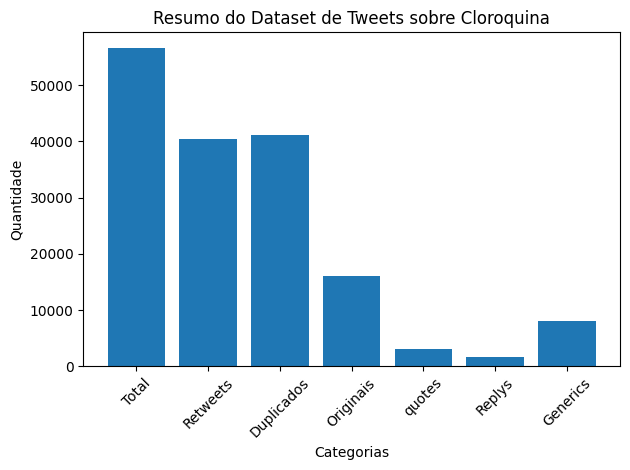

In [78]:
#Grafico resumindo:
total = num_tweets
retweets = num_rt
originais = num_tweets_or
duplicados_qtd = len(duplicados)
num_quotes = len(quotes)
num_replys = len(replys)
num_generics = len(generics)

labels = ["Total", "Retweets",  "Duplicados", "Originais", "quotes","Replys", "Generics"]
values = [total, retweets, duplicados_qtd, originais, num_quotes, num_replys, num_generics]

plt.figure()
plt.bar(labels, values)
plt.title("Resumo do Dataset de Tweets sobre Cloroquina")
plt.xlabel("Categorias")
plt.ylabel("Quantidade")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


In [79]:
#definindo classes de tweets - 0 Generics, 1 replys, 2 quotes

def classification (tweet_bas):
  #tweet generico (is_reply e is_quote = false)
    if (tweet_bas['is_reply'] == False) & (tweet_bas["is_quote"] == False):
      return 0
  #tweet reply (is_reply = True e is_quote = False)
    elif (tweet_bas['is_reply'] == True) & (tweet_bas["is_quote"] == False):
      return 1
  #Caso contrario é quote (sobreposição de reply e quote é quote, considerado aqui)
    else:
      return 2
df["class"] = df.apply(classification, axis = 1) #normalmente 'aply' opera numa coluna inteiro (axis = 0). Para pegar todas, axis = 1

In [80]:
df

,tweet_id,user_id_original,text,created_at_original,retweet_count,like_count,is_retweet,retweeter_user_id,retweet_created_at,is_quote,quoted_tweet_id,quoted_user_id,quoted_text,is_reply,reply_to_tweet_id,reply_to_user_id,reply_to_screen_name,reply_text,class
0,1250542322313560064,1053003526052474881,"STF, o câncer do Brasil, agora quer decidir qu...",Wed Apr 15 21:51:38 +0000 2020,54,85,True,1015738630411902978,Wed Apr 15 22:56:26 +0000 2020,False,None,None,,False,None,None,None,,0
1,1250524480134361089,3062568484,#AbortoNAO é da sua conta se o corpo nao é se...,Wed Apr 15 20:40:44 +0000 2020,246,736,True,1073292364326801408,Wed Apr 15 22:56:26 +0000 2020,False,None,None,,False,None,None,None,,0
2,1250558630656704517,1044570099074650112,Alô STF... repitam comigo: #AbortoNao,Wed Apr 15 22:56:26 +0000 2020,0,0,False,None,None,False,None,None,,False,None,None,None,,0
3,1250531402355036165,1087259768,STF quer aplicar a medida enquanto a gente não...,Wed Apr 15 21:08:14 +0000 2020,1436,4040,True,87768090,Wed Apr 15 22:56:26 +0000 2020,False,None,None,,False,None,None,None,,0
4,1250550843599970308,350476403,"O que a Bíblia fala sobre o aborto? ""Antes qu...",Wed Apr 15 22:25:29 +0000 2020,144,418,True,1221110775424737284,Wed Apr 15 22:56:26 +0000 2020,False,None,None,,False,None,None,None,,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
56526,1250878804639322112,1222107818054033408,Calma cadelinha d Soros Perdeu a linha Pegou g...,Thu Apr 16 20:08:41 +0000 2020,0,0,False,None,None,False,None,None,,True,1250876760188739586,1112838858515865600,smaaxe,,1
56536,1250878960520572931,765543343581528064,é um direito sim! Mais vale abortar logo do qu...,Thu Apr 16 20:09:19 +0000 2020,0,0,False,None,None,True,1250788117386330115,605414528,Já que tenho útero posso opinar. Aborto é imor...,False,None,None,None,,2
56539,1250878992175030278,709698858,Esses dois são judeus? Não sabia,Thu Apr 16 20:09:26 +0000 2020,0,0,False,None,None,True,1250861271974584321,172572347,S/ aborto e eventual voto de Fux e Barroso: a...,False,None,None,None,,2
56548,1250879142687584261,1222610949728886785,"No dia 24, na próxima semana, o STF vai votar ...",Thu Apr 16 20:10:02 +0000 2020,0,0,False,None,None,False,None,None,,False,None,None,None,,0


In [81]:
df[df['tweet_id'].str.contains('1250533884296601603', na=False)]

,tweet_id,user_id_original,text,created_at_original,retweet_count,like_count,is_retweet,retweeter_user_id,retweet_created_at,is_quote,quoted_tweet_id,quoted_user_id,quoted_text,is_reply,reply_to_tweet_id,reply_to_user_id,reply_to_screen_name,reply_text,class


In [82]:
df[df['reply_text'].str.contains('eu vendo a #AbortoNAO subir e lembrando dessas', na=False)]

,tweet_id,user_id_original,text,created_at_original,retweet_count,like_count,is_retweet,retweeter_user_id,retweet_created_at,is_quote,quoted_tweet_id,quoted_user_id,quoted_text,is_reply,reply_to_tweet_id,reply_to_user_id,reply_to_screen_name,reply_text,class


In [83]:
#classe 0
sum_class_0 = int ((df['class'] == 0).sum())
sum_class_0


8146

In [84]:
#Classe 1
sum_class_1 = int ((df['class'] == 1).sum())
sum_class_1

4191

In [85]:
#classe 2
sum_class_2 = int ((df['class'] == 2).sum())
sum_class_2

3045

In [86]:
#convertendo para csv
df.to_csv("aborto.csv", index=False, encoding="utf-8")
files.download("aborto.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>